# TP: Machine Learning

## TP1: Linear Regression (4h)  

Linear regression is a family of machine learning algorithms aiming at adjusting a linear model to an ensemble of data. The applications range from signal reconstruction to empirical description.

The given dataset was produced by the World Health Organization. It pooled the evolution of 20 features for 15 years and among numerous countries. One of the goals of this TP1 is to manipulate this dataset and try to predict the evolution of Life Expectancy through different variables.

**Objectives:**
- Use and setup an iPython environment
- Manipulate and visualize data
- Implement a simple linear regression
- Apply the aforementioned linear regression
- Compute a $R^2$ on the generated results
- Apply Ridge and Lasso regressions


To code this TP, you can use your own iPython environment, or chose to use the ENSEA's jupyter server available on https://io.ensea.fr

This TP has different **checkpoints**. Please call your teacher at the end of each checkpoint to validate your work. Any non validated work won't be taken into account in the notation


## STEP 1: Use and setup an iPython environment

iPython and Notebook environments are useful tools to quickly prototype and test machine learning solutions. However, they have limitations especially in RAM and disk access.

**TO DO 1.1**

Execute the following cells

In [164]:
a = 3
b = 4
c = a + b

In [165]:
c = c

In [166]:
print(c)

7


In [167]:
c

7

**QUESTION 1**

What is triggering the output display?
->L'excécution de la cellule

**TO DO 1.2**

Execute the following cells

In [168]:
import shutil
import pkgutil

def show_acceptable_modules():
    line = '-' * 100
    print('{}\n{:^30}|{:^20}\n{}'.format(line, 'Module', 'Location', line))
    for entry in pkgutil.iter_modules():
        print('{:30}| {}'.format(entry[1], entry[0].path))

In [169]:
#show_acceptable_modules()

**QUESTION 2**

What is displayed on the last output?
->.iter_modules() is a function of pkgutil's module which lets us see the available module in a given repertory. On the left is displayed modules and on the right is repertory to find it.


Which is the used Python version?
->Python 3.11.11

For this TP1, you will need:
- pandas
- matplotlib
- numpy
- sklearn

Are these packages installed in this environment? ->Good

**TO DO 1.3**

Execute the following cell

In [170]:
import pandas
pandas.__version__

'2.2.3'

**QUESTION 3**

How would you solve this error?->import pandas (I didn't use Internet)

## STEP 2: Data manipulation and visualization


**TO DO 2.1**

Execute the following cell

In [171]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/nicol/Downloads/Life_Expectancy_Data.csv")
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1649 non-null   object 
 1   Year                             1649 non-null   int64  
 2   Status                           1649 non-null   object 
 3   Life_expectancy                  1649 non-null   float64
 4   Adult_mortality                  1649 non-null   float64
 5   Infant_deaths                    1649 non-null   int64  
 6   Alcohol                          1649 non-null   float64
 7   Percentage_expenditure           1649 non-null   float64
 8   Hepatitis_B                      1649 non-null   float64
 9   Measles                          1649 non-null   int64  
 10  BMI                              1649 non-null   float64
 11  Under-five_deaths                1649 non-null   int64  
 12  Polio                    

**QUESTION 4**

Can you explain the different elements printed on the last output?
->It gives the $$caracteristics of our predictor variable$$ (they can be represented like a 22-dimensional vector), its count and the its type.

In [172]:
df1 = df[(df.Country == "France") & (df.Year > 2010)]
print("df1: ", df1)
df2 = df[(df.Country == "France")]["Year"]
print("df2: ", df2)

df1:      Country  Year  ... Income_composition_of_resources  Schooling
931  France  2014  ...                           0.890       16.2
932  France  2013  ...                           0.887       16.2
933  France  2012  ...                           0.885       16.1
934  France  2011  ...                           0.882       16.1

[4 rows x 22 columns]
df2:  931    2014
932    2013
933    2012
934    2011
935    2010
936    2009
937    2008
938    2007
939    2006
940    2005
941    2004
942    2003
943    2002
944    2001
945    2000
Name: Year, dtype: int64


**QUESTION 5**

How do you interpret the new Data Frame df1 compared to df? What represents df2 compared to df1?->in df1 and df2 we give criterias to respect by the table. In df2 .Year precise that additionnaly we want only to extract the column's Year information.

**TO CODE 2.2**

What is the range of life expectancy of Belgium between 2004 and 2008? ->[78.8,79.5]

In [173]:
#Same as df3=df[(df.Country=="Belgium") & (df.Year <=2008) & (df.Year >= 2004)]["Life_expectancy"]
df3=df[(df.Country=="Belgium") & (df.Year <=2008) & (df.Year >= 2004)].Life_expectancy
print("df3: ", df3)


df3:  247    79.5
248    79.5
249    79.4
250    78.9
251    78.8
Name: Life_expectancy, dtype: float64


**TO DO 2.3**

Compute the correlation among all features

In [174]:
import numpy as np
#print(df['Albania'])
#df4=df[].Life_exp
print(df.select_dtypes(include='number').corr()) #Countries names cannot be used for corrélation
# Dépendance entre deux phénomènes, indiquant un effet de causalité ou une fonction d'interdépendance. [IN FRENCH]
for element in df :
    if (element != "Country") and (element != "Status"):
        print(element + " : " + str( df.select_dtypes(include='number').corr()["Life_expectancy"][element]) )

                                     Year  ...  Schooling
Year                             1.000000  ...   0.088732
Life_expectancy                  0.050771  ...   0.727630
Adult_mortality                 -0.037092  ...  -0.421171
Infant_deaths                    0.008029  ...  -0.214372
Alcohol                         -0.113365  ...   0.616975
Percentage_expenditure           0.069553  ...   0.422088
Hepatitis_B                      0.114897  ...   0.215182
Measles                         -0.053822  ...  -0.115660
BMI                              0.005739  ...   0.554844
Under-five_deaths                0.010479  ...  -0.226013
Polio                           -0.016699  ...   0.350147
Total_expenditure                0.059493  ...   0.243783
Diphtheria                       0.029641  ...   0.350398
HIV_AIDS                        -0.123405  ...  -0.211840
GDP                              0.096421  ...   0.467947
Population                       0.012567  ...  -0.040312
Thinness _1-19

La corrélation est une mesure statistique qui indique le degré de relation entre deux variables. 
Elle est souvent exprimée par le coefficient de corrélation, qui est défini par la formule suivante :

ρ(X,Y)= $$Cov(X,Y)*/sqrt(Var(X).Var(Y)$$
où Cov(X,Y) est la covariance entre les variables X et Y, et Var(X) et Var(Y) sont les variances respectives de ces variables. Le coefficient de corrélation peut varier entre -1 et 1, où 0 indique une corrélation nulle, 1 indique une corrélation positive (ou linéaire) et -1 indique une corrélation négative (ou inverse).

**QUESTION 6**

Which seems the most and the least promising values to use as a predictor for life expectancy? 

->The most promising values are the one where the absolute value is the closest to 1 including : Adult_mortality/Schooling and the Income_composition_of_ressources. 
->The least pronmising are the ones closest to 0 including : Population/Infant_deaths/Measles.

The function scatter of matplotlib allows to plot two values against each other. Here is the documentation about this function:

```
matplotlib.pyplot.scatter(x, y, s=None, c=None, marker=None, cmap=None, norm=None, vmin=None, vmax=None, alpha=None, linewidths=None, *, edgecolors=None, plotnonfinite=False, data=None, **kwargs)
```
Parameters:

**x, y** float or array-like, shape (n, )

The data positions.

**s** float or array-like, shape (n, ), optional

The marker size in points**2. Default is rcParams['lines.markersize'] ** 2.

**c** array-like or list of colors or color, optional

The marker colors. Possible values:

- A scalar or sequence of n numbers to be mapped to colors using cmap and norm.

- A 2D array in which the rows are RGB or RGBA.

- A sequence of colors of length n.

- A single color format string.

**marker** MarkerStyle, default: rcParams (default: 'o')

The marker style. marker can be either an instance of the class or the text shorthand for a particular marker. See matplotlib.markers for more information about marker styles.

**cmapstr** or Colormap, default: rcParams(default: 'viridis')

A Colormap instance or registered colormap name. cmap is only used if c is an array of floats.

**norm** Normalize, default: None

If c is an array of floats, norm is used to scale the color data, c, in the range 0 to 1, in order to map into the colormap cmap. If None, use the default colors.Normalize.

**vmin, vmax** float, default: None

vmin and vmax are used in conjunction with the default norm to map the color array c to the colormap cmap. If None, the respective min and max of the color array is used. It is deprecated to use vmin/vmax when norm is given.

**alpha** float, default: None

The alpha blending value, between 0 (transparent) and 1 (opaque).

**linewidths** float or array-like, default: rcParams (default: 1.5)

The linewidth of the marker edges. Note: The default edgecolors is 'face'. You may want to change this as well.

**edgecolors** {'face', 'none', None} or color or sequence of color, default: rcParams["scatter.edgecolors"] (default: 'face')

The edge color of the marker. Possible values:

- 'face': The edge color will always be the same as the face color.

- 'none': No patch boundary will be drawn.
        
- A color or sequence of colors.

For non-filled markers, edgecolors is ignored. Instead, the color is determined like with 'face', i.e. from c, colors, or facecolors.

**plotnonfinite** bool, default: False

Whether to plot points with nonfinite c (i.e. inf, -inf or nan). If True the points are drawn with the bad colormap color (see Colormap.set_bad).


**TO CODE 2.4**

Plot life expectancy against one of your chosen values.

-> The corrrelation between Life_expectancy and Schooling is pertinent (seems to follow an affine function) however there a lot of outliers for a schooling of 0 (list to be seen below).

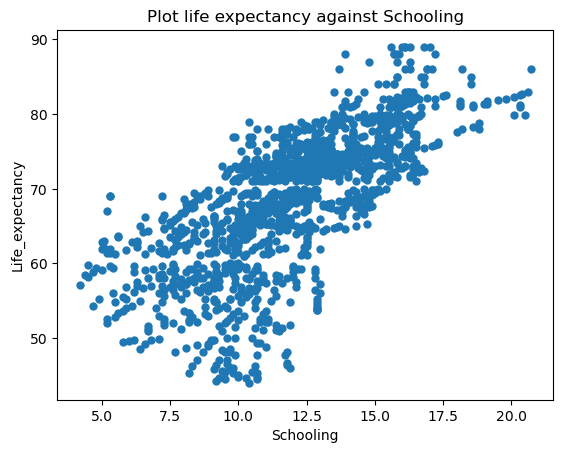

Empty DataFrame
Columns: [Country, Year, Status, Life_expectancy, Adult_mortality, Infant_deaths, Alcohol, Percentage_expenditure, Hepatitis_B, Measles, BMI, Under-five_deaths, Polio, Total_expenditure, Diphtheria, HIV_AIDS, GDP, Population, Thinness _1-19_years, Thinness_5-9_years, Income_composition_of_resources, Schooling]
Index: []


In [175]:
import matplotlib.pyplot as plt

plt.scatter(df["Schooling"],df["Life_expectancy"],linewidths=0)
plt.ylabel("Life_expectancy")
plt.xlabel("Schooling")
plt.title("Plot life expectancy against Schooling")
plt.show()

print(df[(df.Schooling == 0)])

## Checkpoint : 1 
Call your teacher to validate the parts 1 and 2

## STEP 3: Simple Linear Regression

In [176]:
import numpy as np

**TO CODE 3.1**

Select the Life Expectancy and the Income composition of resources of Belarus, Madagascar, India and Lithuania. This new Data Frame will be called df_study

In [177]:
pays = ["Belarus", "Madagascar", "India", "Lithuania"]
df_study={}
for element in pays :
    df_study[element] = [df[(df.Country==element)]["Life_expectancy"],df[(df.Country==element)]["Income_composition_of_resources"]]


**TO CODE 3.2**

Implement a simple least square function and apply it on the previous selected data.

In [178]:
def least_squares(x,y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    a =np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
    b=y_mean-a*x_mean
    return a,b

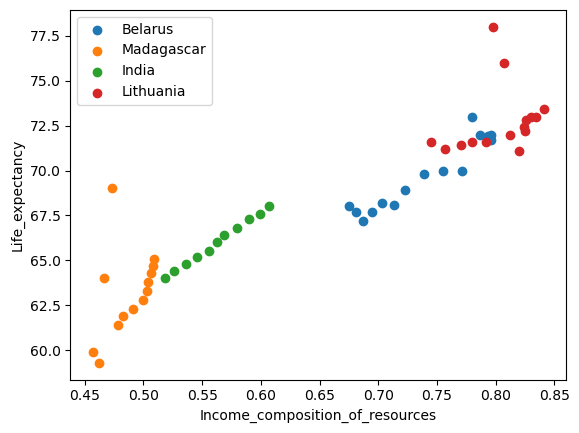

28.5982261406769 49.347635188332305


In [179]:
y_Life_expectancy=[]
x_Income=[]
y_Life_expectancy_Country=[]
x_Income_Country=[]

#To plot while separating the countries
for element in df_study :
    for numbers_y in df_study[element][0].values : #values is useful to extract values from special forms
         y_Life_expectancy.append(numbers_y)
    for numbers_x in df_study[element][1].values :
         x_Income.append(numbers_x)
    x_Income_Country.append(x_Income.copy())
    y_Life_expectancy_Country.append(y_Life_expectancy.copy())
    y_Life_expectancy=[]
    x_Income=[]

for i in range(len(x_Income_Country)):
    plt.scatter(x_Income_Country[i],y_Life_expectancy_Country[i],label=pays[i])

plt.xlabel("Income_composition_of_resources")
plt.ylabel("Life_expectancy")

plt.legend()  
plt.show()

#To calculate bhat1,bhat0
for element in df_study :
    for numbers_y in df_study[element][0].values : #values is useful to extract values from special forms
         y_Life_expectancy.append(numbers_y)
    for numbers_x in df_study[element][1].values :
         x_Income.append(numbers_x)

bhat1,bhat0=least_squares(x_Income,y_Life_expectancy)
print(bhat1,bhat0)

The countries selected all have the income_composition getting higher with their life_expectancy like India being clearly linear. The contries chosen don't have their income_composition too much in common to expand the span of income_composition (and confirming the domain where linearity apply.

**TO CODE 3.3**

On the same figure, draw the line corresponding to your regression and the data points corresponding to df_study

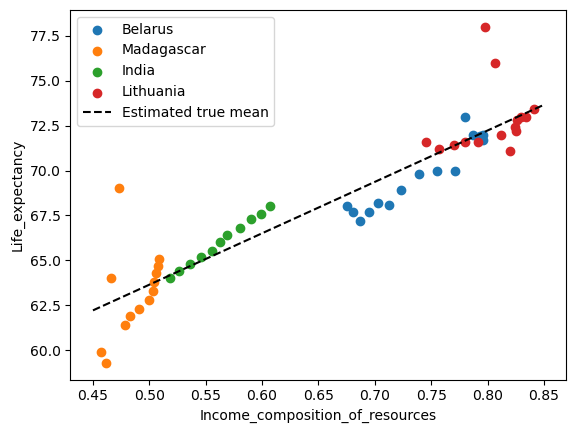

In [180]:
f = lambda x : bhat1*x+bhat0
x = np.linspace(0.45,.85,5) #To plot the line two points are only necessary
for i in range(len(x_Income_Country)):
    plt.scatter(x_Income_Country[i],y_Life_expectancy_Country[i],label=pays[i])
plt.plot(x,f(x), linestyle="--", color = "Black",label="Estimated true mean")
plt.xlabel("Income_composition_of_resources")
plt.ylabel("Life_expectancy")
plt.legend()  
plt.show()

The line plotted is going through the data given by the 4 countries with the slope $$y Life expectancy = x Income Composition*28.5982261406769 + 49.347635188332305$$


## Checkpoint : 2
Call your teacher to validate the least square section

**TO CODE 3.4**

Now, implement a Gradient Descend function `def gradDescent(x, y, w, alpha, iters)` where `x` are
the covariates, `y` the target value, `w` the initial weights, `alpha` the learning rate and `iters` the number of gradient descent iterations. Your function should return all intermediary values of `w` that has been computed as a list.

As a gentle reminder, Gradient Descent is an optimization algorithm for finding a local minimum of a differentiable function. It is an iterative algorithm that aim to find the `w`  that minimizes our objective function. Since we aim to minimize the squared error, we aim to minimize the function : $L(y, \hat{y})=\sum\limits_{i=1}^n (y_i - w_1x_i-w_0)^2 $

Since previous function is convex, the derivative at each point indicate the **opposite** direction of the minimum. Thus, the idea is to update each weight by a small proportion of the opposite of this direction : 
$w_i^{t+1} = w_i^t - \alpha \frac{d(L(y, \hat{y}))}{d(w_i)}$

Be careful : here we have to update two weights, so we have to compute both derivative. Pay also attention on the fact that the derivative is computed according to $w_i$. Once you noticed that, calculating the derivative is pretty straightforward

Weights : w1 = 28.5490 , w0 = 49.2740


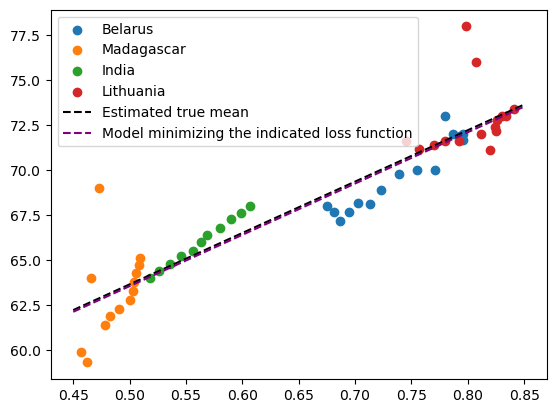

In [181]:
def gradDescent(x,y,w,alpha,iters):
    #We start with w1 = bhat1 and w2 = bhat2 / arbitrary ideal case / if our data is not close to this line we have a model issue
    #(w1,w0)=least_squares(x,y) used first but it was the answer
    w1,w0=w
    for i in range(iters) :
        #Calculus of the derivation by w1 for t+1 :
        dw1 = 2*(w1*np.dot(x,x)-np.dot(x,y)+w0*np.sum(x))
        #Calculus of w2 for t+1 :
        dw0= 2*(w0*len(y)+np.sum(x)*w1-np.sum(y))
        #Calculus of the weights
        w0=w0-alpha*dw0
        w1=w1-alpha*dw1
        #print(alpha*2*(w0*len(y)+np.sum(x_mult_by_w1)-np.sum(y)))
    return w1,w0
""" #Thanks to Copilot
def gradDescent(x, y, alpha, iters):
    #(w1,w0)=least_squares(x,y)
    w1,w0=0,0
    for t in range(iters):
        y_pred = [w1 *x[i] + w0 for i in range(len(x))] 
        dw1 = -2 * np.sum([x[i] * (y[i] - y_pred[i]) for i in range(len(x))])
        dw0 = -2 * np.sum([y[i] - y_pred[i] for i in range(len(x))])

        w1 -= alpha * dw1
        w0 -= alpha * dw0

        loss = np.sum([(y[i] - y_pred[i])**2 for i in range(len(y))])
        print(f"Iter {t}: Loss={loss:.4f} | w1={w1:.4f} | w0={w0:.4f}")

    return w1, w0
"""
    
#To plot our result foung by iteration
b1,b0 = gradDescent(x_Income,y_Life_expectancy,(0,0),0.0128,1000) #We're close to divergence with 0.0128/ (0,0) arbitrary
print(f"Weights : w1 = {b1:.4f} , w0 = {b0:.4f}")
fgd = lambda x2 : b1*x2+b0
x = np.linspace(0.45,.85,5) #To plot the line two points are only necessary


#Plotting comparaison
for i in range(len(x_Income_Country)):
    plt.scatter(x_Income_Country[i],y_Life_expectancy_Country[i],label=pays[i])
plt.plot(x,f(x), linestyle="--", color = "Black",label="Estimated true mean")
plt.plot(x,fgd(x), linestyle="--", color = "Purple",label="Model minimizing the indicated loss function")

plt.legend()
plt.show()

We observe that the Model with the loss function converges toward the true mean estimate. It means that either the outliers are negligeable compared by the data gathered (then gives a good reason to eliminate them if the data is well distributed) or that the outliers cancels out (there it's the case - outliers at the beginning and the end).

Weights : w1 = 28.5967 , w0 = 49.3454


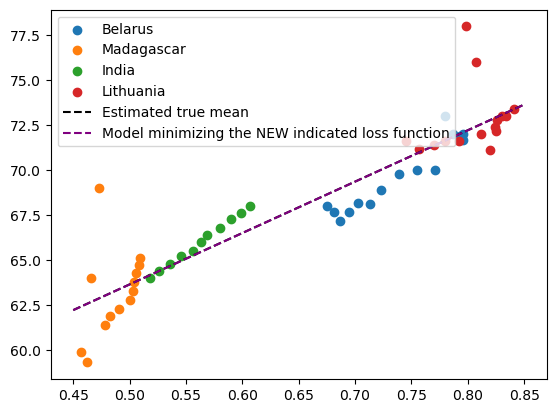

In [182]:
#Another way to calculate the descent with a completly new Loss Function
def gradDescent2(x, y, w, alpha, iters):
    m = len(y)
    w_history = [w]
    x = np.c_[np.ones((len(X), 1)), x]

    for i in range(iters):
        predictions = np.dot(x, w)
        error = predictions - y
        gradient = (1/m) * np.dot(x.T, error)
        w = w - alpha * gradient
        w_history.append(w)
        
    return w_history
    
w_history0 = gradDescent2(x_Income,y_Life_expectancy,(0,0),1.38,1000) #We're close to divergence with 0.0128/ (0,0) arbitrary
b0,b1 = w_history0[len(w_history)-1]
print(f"Weights : w1 = {b1:.4f} , w0 = {b0:.4f}")
fgd1 = lambda x2 : b1*x2+b0
x = np.linspace(0.45,.85,5) #To plot the line two points are only necessary


for i in range(len(x_Income_Country)):
    plt.scatter(x_Income_Country[i],y_Life_expectancy_Country[i],label=pays[i])
plt.plot(x,f(x), linestyle="--", color = "Black",label="Estimated true mean")
plt.plot(x,fgd1(x), linestyle="--", color = "Purple",label="Model minimizing the NEW indicated loss function")

plt.legend()
plt.show()

The new method is less efficient (below we explain that alpha is directly correlated to speed), however it's more stable alpha = 1 do not diverge. It diverges towards 1.38.
This method still gives us the same answer found before. The choice of the Loss function seems to directly influence the alpha to be put.

**TO CODE 3.5**

Compute the gradient descend on df_study for 1000 iterations with different values of `alpha`. You
may initialize `theta` with `theta_0 = 0` and `theta_1 = 1`

In [183]:
iterations = 1000
alphas = [0.001, 0.01, 0.1, 1]
#The variable to calculate bhat1,bhat0 are reused (see end 3.2)
for alpha in alphas:
    weights = gradDescent(x_Income, y_Life_expectancy,(0,0), alpha, iterations) 
    print(f"  Alpha = {alpha}:")
    print(f"  theta_0 : {weights[1]:.4f}")
    print(f"  theta_1 : {weights[0]:.4f}\n")

  Alpha = 0.001:
  theta_0 : 48.8021
  theta_1 : 29.4137

  Alpha = 0.01:
  theta_0 : 49.3476
  theta_1 : 28.5982

  Alpha = 0.1:
  theta_0 : nan
  theta_1 : nan

  Alpha = 1:
  theta_0 : nan
  theta_1 : nan



C:\Users\nicol\AppData\Local\Temp\ipykernel_20204\1556405143.py:7: RuntimeWarning: overflow encountered in scalar multiply
  dw1 = 2*(w1*np.dot(x,x)-np.dot(x,y)+w0*np.sum(x))
C:\Users\nicol\AppData\Local\Temp\ipykernel_20204\1556405143.py:9: RuntimeWarning: overflow encountered in scalar multiply
  dw0= 2*(w0*len(y)+np.sum(x)*w1-np.sum(y))
C:\Users\nicol\AppData\Local\Temp\ipykernel_20204\1556405143.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  w0=w0-alpha*dw0
C:\Users\nicol\AppData\Local\Temp\ipykernel_20204\1556405143.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  w1=w1-alpha*dw1


As said in the code from 3.4, the limit of convergence is towards 0.0128. All values above are converges towards infinity.

**TO CODE 3.6**

On the same figure, plot the evolution of theta_0 through the iterations for each different values of
alpha you chose. Do the same thing for theta_1.

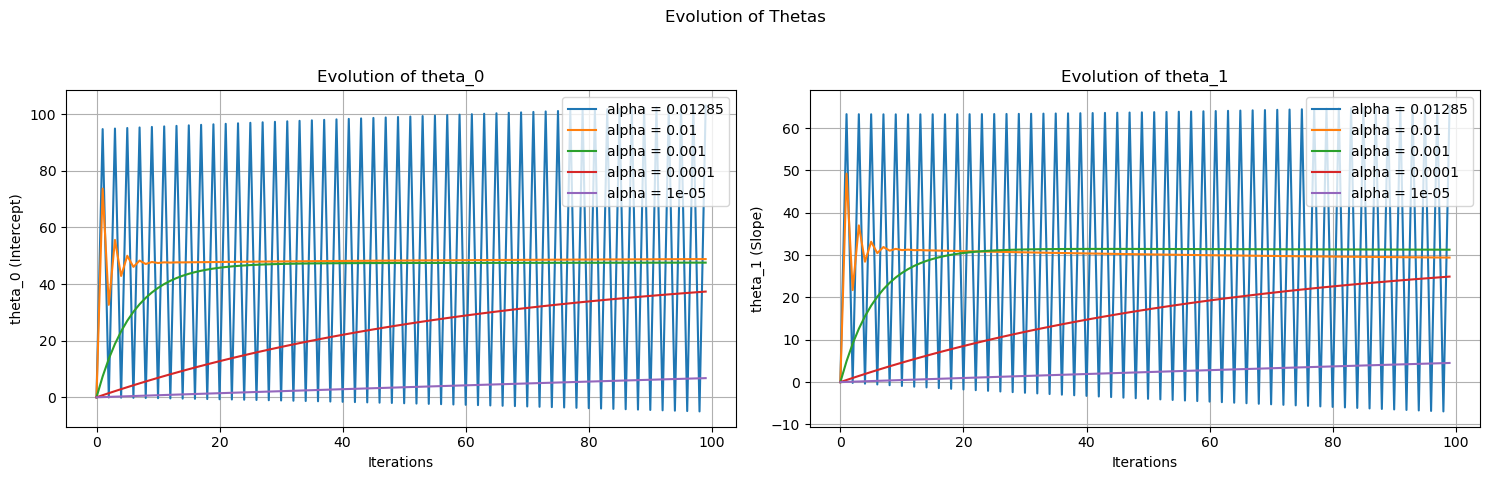

In [184]:
X = x_Income
y = y_Life_expectancy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Evolution of Thetas')
theta0_history=[]
theta1_history=[]

#Alpha is modified else errors
alphas=[0.01285,0.01,0.001,0.0001,0.00001]

for alpha in alphas:
    for i in range(100) :
        weights_history = gradDescent(X, y,(0,0), alpha, i)
        theta0_history.append(weights_history[1])
        theta1_history.append(weights_history[0])
    ax1.plot(np.arange(len(theta0_history)), theta0_history, label=f'alpha = {alpha}')
    ax2.plot(np.arange(len(theta1_history)), theta1_history, label=f'alpha = {alpha}')
    theta0_history=[]
    theta1_history=[]

ax1.set_xlabel('Iterations')
ax1.set_ylabel('theta_0 (Intercept)')
ax1.set_title('Evolution of theta_0')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel('Iterations')
ax2.set_ylabel('theta_1 (Slope)')
ax2.set_title('Evolution of theta_1')
ax2.legend()
ax2.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Question 7**

Discuss on the role of alpha
-> The higher alpha is, the faster the weights are determined from alpha = 0.01 to alpha = 10e-5. However after a threshold (proving that an alpha_optimum exists), the instability makes the convergence slower. If alpha is taken even higher it becomes a divergence.
Alpha is correlated to the speed and stability of our iterative research of the weights. It could be assimilated to the damping factor of a 2nd order system.

$R^2$ is the coefficient of determination useful to score a regression against the ground truth data.

This coefficient can be computed with a sklearn function:

```
sklearn.metrics.r2_score(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')
```

With:

**y_true** array-like of shape (n_samples,) or (n_samples, n_outputs)

Ground truth (correct) target values.

**y_pred** array-like of shape (n_samples,) or (n_samples, n_outputs)

Estimated target values.

**sample_weight** array-like of shape (n_samples,), default=None

Sample weights.

**multioutput** {‘raw_values’, ‘uniform_average’, ‘variance_weighted’}, array-like of shape (n_outputs,) or None, default=’uniform_average’

Defines aggregating of multiple output scores. Array-like value defines weights used to average scores. Default is “uniform_average”.

- ‘raw_values’: Returns a full set of scores in case of multioutput input.

- ‘uniform_average’: Scores of all outputs are averaged with uniform weight.

- ‘variance_weighted’: Scores of all outputs are averaged, weighted by the variances of each individual output.


In [185]:
from sklearn.metrics import r2_score

**TO CODE 3.7**

Compute $R^2$ on the regression with df_study

In [186]:
#Alpha =0.1 here with iters = 1000
b1,b0 = gradDescent(x_Income,y_Life_expectancy,(0,0),0.01,1000)
y_pred = [b1*x_Income[i]+b0 for i in range(len(x_Income))]
y_seen = y_Life_expectancy
r2 = r2_score(y_seen, y_pred)
print(f"  R-squared score: {r2:.4f}\n")

  R-squared score: 0.8466



**QUESTION 8**

Is linear regression suited between the two selected variables? -> The linear model is pertinent but not ideal due to non negligeable variance (we consider that the model is truly linear if $R^2 > 0.95$ ).

**QUESTION 9**

If not, what would be the relevant regression between these two variables? -> It depends of how the data is distributed so then we must not use a linear model (a polynomial one or else would have been more profitable).

## Checkpoint : 3
Call your teacher to validate the rest of section 3

## STEP 4: Diagnostic visualization

**TO CODE 4.1**

Compute the residuals and plot the residuals vs fitted values.

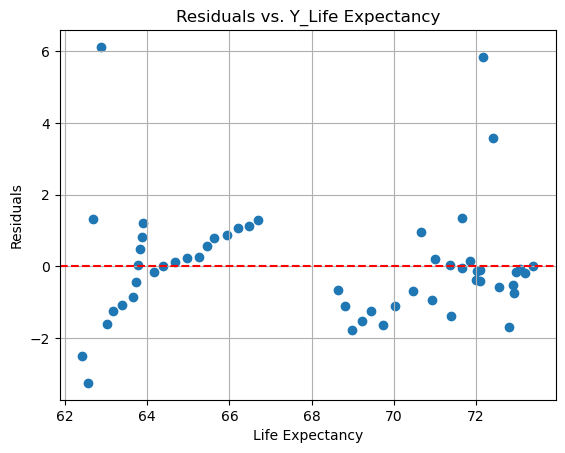

In [187]:
residuals = [y_seen[i] - y_pred[i] for i in range(len(y_seen))]

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Life Expectancy")
plt.ylabel("Residuals")
plt.title("Residuals vs. Y_Life Expectancy")
plt.grid(True)
plt.show()

**Question 10**

What can you conclude about this plot ? -> Almost no points are on the line (however the scale of y-axis is misleading due to a light zoom). The linear lines corresponding to the **yearly** Income Compo/Life Expectancy of each contries pointed earlier clearly diverges by the years going on.

Moreover this chart exacerbates the outliers that are the datas where the absolute value of the residuals is above 2. These residuals are mainly present at the beginning and at the end.

**TO CODE 4.2**

Also compute the Scale Location plot


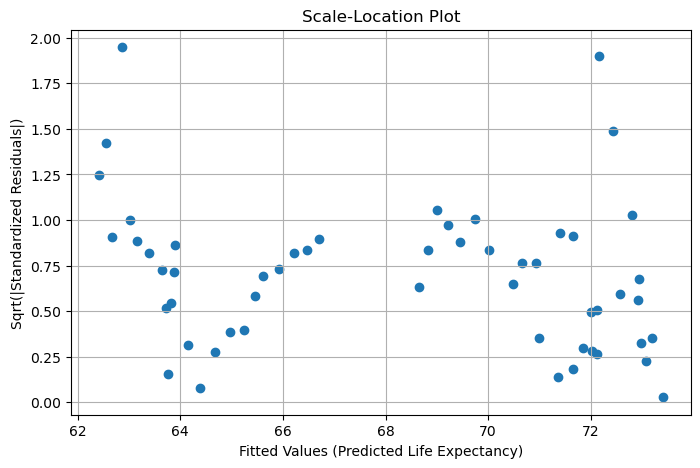

In [188]:
# To create the Scale-Location plot, we need standardized residuals.
# A simple way to approximate this is to scale by the standard deviation.
std_residuals = residuals / np.std(residuals)

# Y-axis for the plot is the square root of the absolute standardized residuals
sqrt_abs_std_residuals = np.sqrt(np.abs(std_residuals))

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, sqrt_abs_std_residuals)
plt.xlabel("Fitted Values (Predicted Life Expectancy)")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot")
plt.grid(True)

**Question 11**

What can you conclude about this plot ? -> We have the same observations (but here I consider that ouliers are the points above 1.2). It's easier to study because to identify the outliers we do not need to define an interval but a threshold .

**TO CODE 4.3**

Compute now the Cook's distance for our data. You can compute it by yourself or use any library you can find.


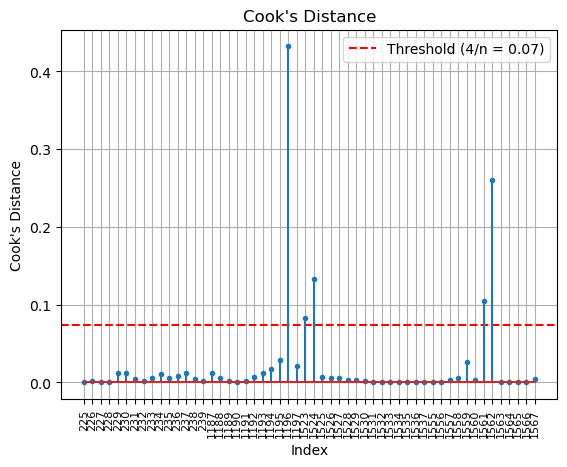

In [196]:
import statsmodels.api as sm

# Adding constant
x_Income = sm.add_constant(x_Income)
model = sm.OLS(y_Life_expectancy, x_Income).fit()

# Influence
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(y)

df_study = df[(df.Country == "Belarus") | (df.Country == "Madagascar") | (df.Country == "India") | (df.Country == "Lithuania")]

plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold (4/n = {threshold:.2f})')
plt.xticks(np.arange(len(cooks_d)), df_study.index, rotation=90, fontsize=8)
plt.stem(cooks_d, markerfmt=".")

plt.xlabel("Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.legend()
plt.grid(True)
plt.show()

**Question 12**

What can you conclude about this plot ? -> Owing to the Internet the most influencal points are the ones greater 4 divided by the sample size (here n). Including the observation of the previous plots, this calculus exacerbates the outliers to highlight their leverage over the fitting model and give us a normalized threshold to identify outliers (however it could be change by how much randomness we accept on our Gaussian noise).


**TO DO 4.1** 

We are now adding multiple variable in our regression problem. Run the following cell in order to add multiple variables to your model : 

In [197]:
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

df_study = df[(df.Country == "Belarus") | (df.Country == "Madagascar") | (df.Country == "India") | (df.Country == "Lithuania")]
y = df_study.Life_expectancy
X = df_study[['Adult_mortality', 'Alcohol', 'Total_expenditure', 'Income_composition_of_resources', 'Schooling', "HIV_AIDS"]].to_numpy(dtype='float64')

**TO CODE 4.4**

Dealing with too many variables can sometimes be counter-productive and it can be more interesting to remove some features. One way to evaluate the importance of each variable is to compute the f_test whose function is named f_regression in sklearn. 

In [198]:
from sklearn.feature_selection import f_regression
feature_names = ['Adult_mortality', 'Alcohol', 'Total_expenditure', 'Income_composition_of_resources', 'Schooling', "HIV_AIDS"]

f_stats, p_values = f_regression(X, y)

f_test_results = pd.DataFrame({
    'Feature': feature_names,
    'F-statistic': f_stats,
    'p-value': p_values
})

print("F-test Results for Feature Importance:")
print(f_test_results)

F-test Results for Feature Importance:
                           Feature  F-statistic       p-value
0                  Adult_mortality     3.864442  5.466967e-02
1                          Alcohol   125.092813  1.891968e-15
2                Total_expenditure    36.729420  1.545113e-07
3  Income_composition_of_resources   287.054376  8.047139e-23
4                        Schooling   261.508960  6.212050e-22
5                         HIV_AIDS   106.622723  3.395111e-14


**QUESTION 13**

According to the f_test, rank each variable from the least to the most promising. Compare it with the correlation of your subset.

In [199]:
f_test_results = f_test_results.sort_values(by='p-value')

print("F-test Results for Feature Importance:")
print(f_test_results)

for element in df :
    if (element in feature_names) :
        print(element + " : " + str( df.select_dtypes(include='number').corr()["Life_expectancy"][element]) )

F-test Results for Feature Importance:
                           Feature  F-statistic       p-value
3  Income_composition_of_resources   287.054376  8.047139e-23
4                        Schooling   261.508960  6.212050e-22
1                          Alcohol   125.092813  1.891968e-15
5                         HIV_AIDS   106.622723  3.395111e-14
2                Total_expenditure    36.729420  1.545113e-07
0                  Adult_mortality     3.864442  5.466967e-02
Adult_mortality : -0.7025230623069735
Alcohol : 0.402718321727354
Total_expenditure : 0.17471764064230505
HIV_AIDS : -0.5922362925926357
Income_composition_of_resources : 0.7210825929172864
Schooling : 0.7276300323211043


-> The issue is that F-static and p-value should indicate how uncorrelated it is from Life_Expectancy. It's only the case for positive correlation and not negative ones. A negative correlation is worst from an uncorrelated/useless feature. To solve this issue we should create a not feature for each negative corrrelation.

## Checkpoint : 4
Call your teacher to validate the section 4. Congrats, you finished the first TP !

In [200]:
print("Yeah")

Yeah
